# Module1. 블랙파우더 성분 데이터 전처리

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 데이터 로드하기

본 연구에서는 습식제련 공정 데이터를 이용하여 금속 회수율을 예측하는 모델을 개발한다.

데이터는 다음 변수로 구성된다.

### 입력 변수 (Features)

- Nickel_Percent
- Lithium_Percent
- Impurity_Percent
- Acid_Amount
- Leaching_Time

### 출력 변수 (Label)

- Recovery_Rate

우선 데이터를 불러오고 기본 구조를 확인한다.

In [ ]:
blackpowder_df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/캡스톤디자인/battery_data.csv')

# 데이터 분포 확인하기

각 변수의 기본 통계량을 확인한다.

이를 통해

- 평균
- 표준편차
- 최소값
- 최대값

등을 파악한다.

In [ ]:
blackpowder_df.describe()

,Nickel_Percent,Lithium_Percent,Impurity_Percent,Acid_Amount,Leaching_Time,Recovery_Rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,55.237092,5.985211,17.504480,55.051478,133.414141,67.588277
std,14.536093,2.310270,7.157327,26.188623,61.797283,11.474707
min,30.001536,2.011791,5.003367,10.053814,30.047678,33.765677
25%,42.601719,3.925114,11.461121,32.038998,79.668797,60.491435
50%,55.417922,6.010160,17.342008,55.914136,133.272109,69.187586
75%,68.229915,7.928602,23.613913,77.297771,188.661371,76.336204
max,79.834843,9.991141,29.992942,99.751411,239.907118,93.728905




*   피처: Nickel_Percent,	Lithium_Percent,	Impurity_Percent,	Acid_Amount,	Leaching_Time
*   라벨: Recovery_Rate



# 결측치 확인

 결측치를 파악한다.

모든 변수에서 결측치가 발견되지 않았다.
따라서 별도의 결측치 처리 과정 없이 분석을 진행한다.

In [ ]:
blackpowder_df.isna().sum()

,0
Nickel_Percent,0
Lithium_Percent,0
Impurity_Percent,0
Acid_Amount,0
Leaching_Time,0
Recovery_Rate,0


# 이상치 확인

이상치를 파악한다.

본 연구에서는 두 가지 방법을 사용하였다.

1. IQR 기반 이상치 탐색
    - 변수별 극단값 확인

2. Isolation Forest 기반 이상치 탐색
    - 여러 변수의 조합을 고려한 이상치 탐색

IQR은 단변량 관점에서 이상치를 탐지하며,
Isolation Forest는 다변량 관점에서 비정상적인 데이터를 탐지할 수 있다.

In [ ]:
numeric_cols = blackpowder_df.columns

outlier_summary = []

for col in numeric_cols:

    Q1 = blackpowder_df[col].quantile(0.25)
    Q3 = blackpowder_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = blackpowder_df[
        (blackpowder_df[col] < lower) |
        (blackpowder_df[col] > upper)
    ]

    outlier_summary.append(
        [col, len(outliers)]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier Count"]
)
outlier_df

,Feature,Outlier Count
0,Nickel_Percent,0
1,Lithium_Percent,0
2,Impurity_Percent,0
3,Acid_Amount,0
4,Leaching_Time,0
5,Recovery_Rate,3


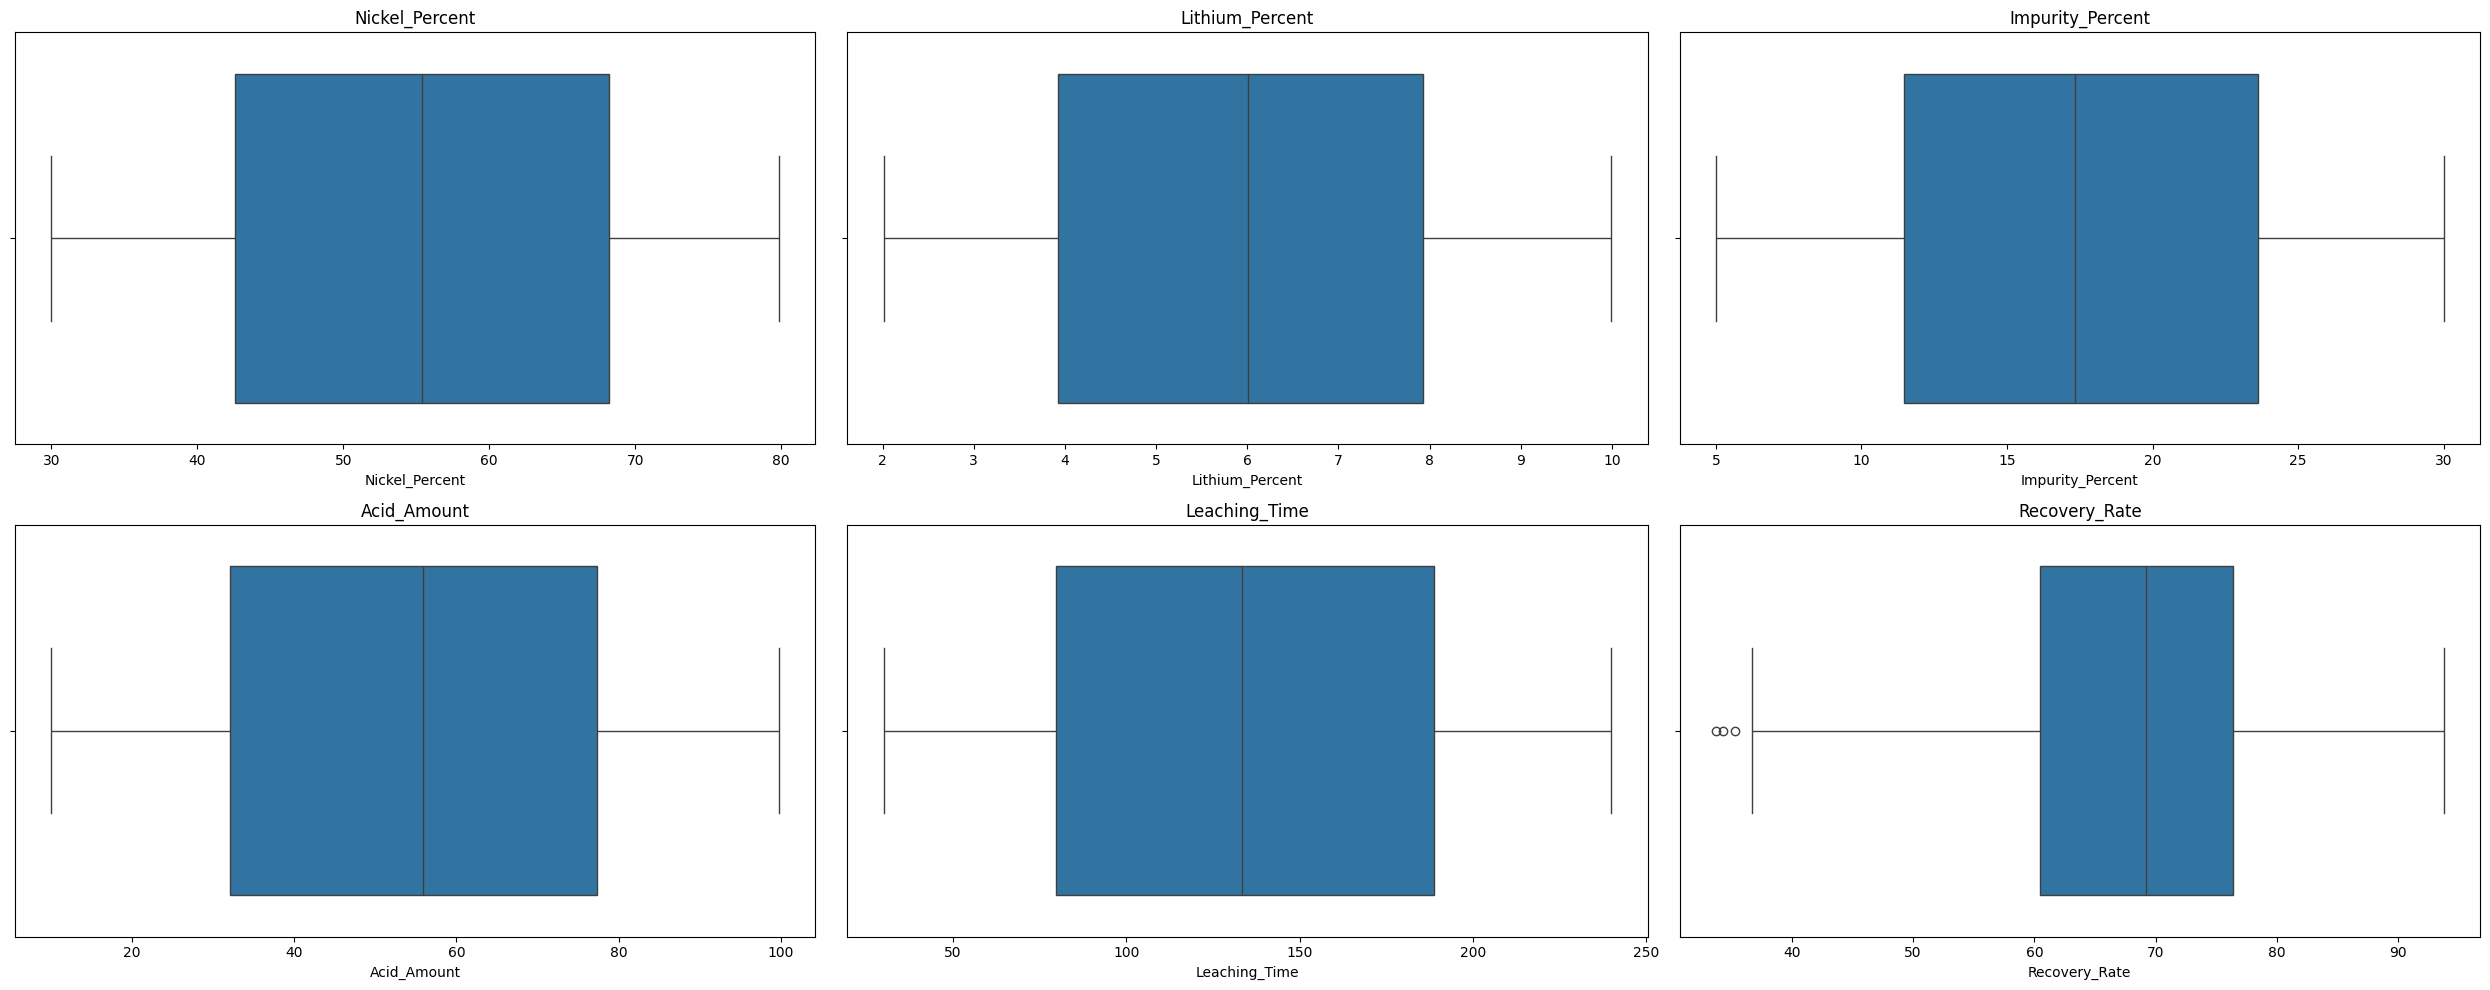

In [ ]:
numeric_cols = blackpowder_df.columns

fig, axes = plt.subplots(2, 3, figsize=(25, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=blackpowder_df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Isolation Forest 기반 이상치 탐색

Isolation Forest는 비지도학습 기반 이상치 탐지 알고리즘이다.

정상 데이터는 서로 밀집되어 있는 반면,
이상치는 적은 분할만으로 쉽게 고립(Isolation)된다는 특성을 이용한다.

본 분석에서는 데이터의 약 5%를 이상치 후보로 탐지하였다.

In [ ]:
from sklearn.ensemble import IsolationForest

X = blackpowder_df.copy()

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_status = iso_forest.fit_predict(X)

# blackpowder_df["Anomaly"] = anomaly_status # Removed: Not adding Anomaly column to blackpowder_df here

In [ ]:
import pandas as pd

pd.Series(anomaly_status).value_counts()

,count
1,950
-1,50


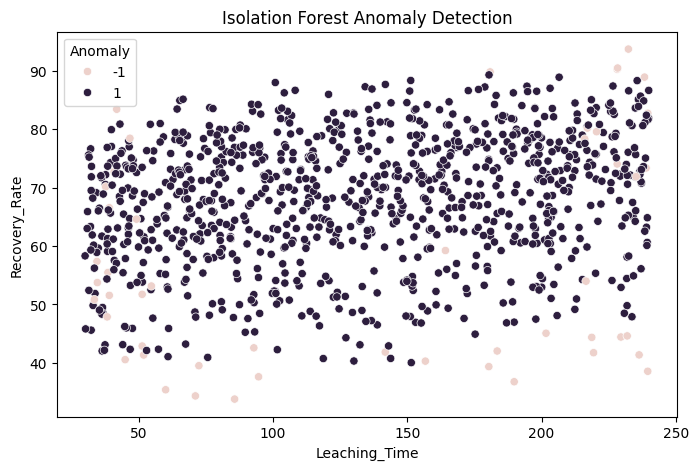

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=blackpowder_df.assign(Anomaly=anomaly_status), # Temporarily assign for plotting
    x="Leaching_Time",
    y="Recovery_Rate",
    hue="Anomaly"
)

plt.title(
    "Isolation Forest Anomaly Detection"
)

plt.show()

# 변수 분포 분석

각 변수의 분포를 확인한다.

변수 분포는

- 데이터 편향 여부
- 특정 구간 집중 현상
- 이상 분포 존재 여부

를 파악하는 데 활용된다.

특히 모델 선택 과정에서 데이터의 비선형성을 추정하는 기초 자료로 활용된다.

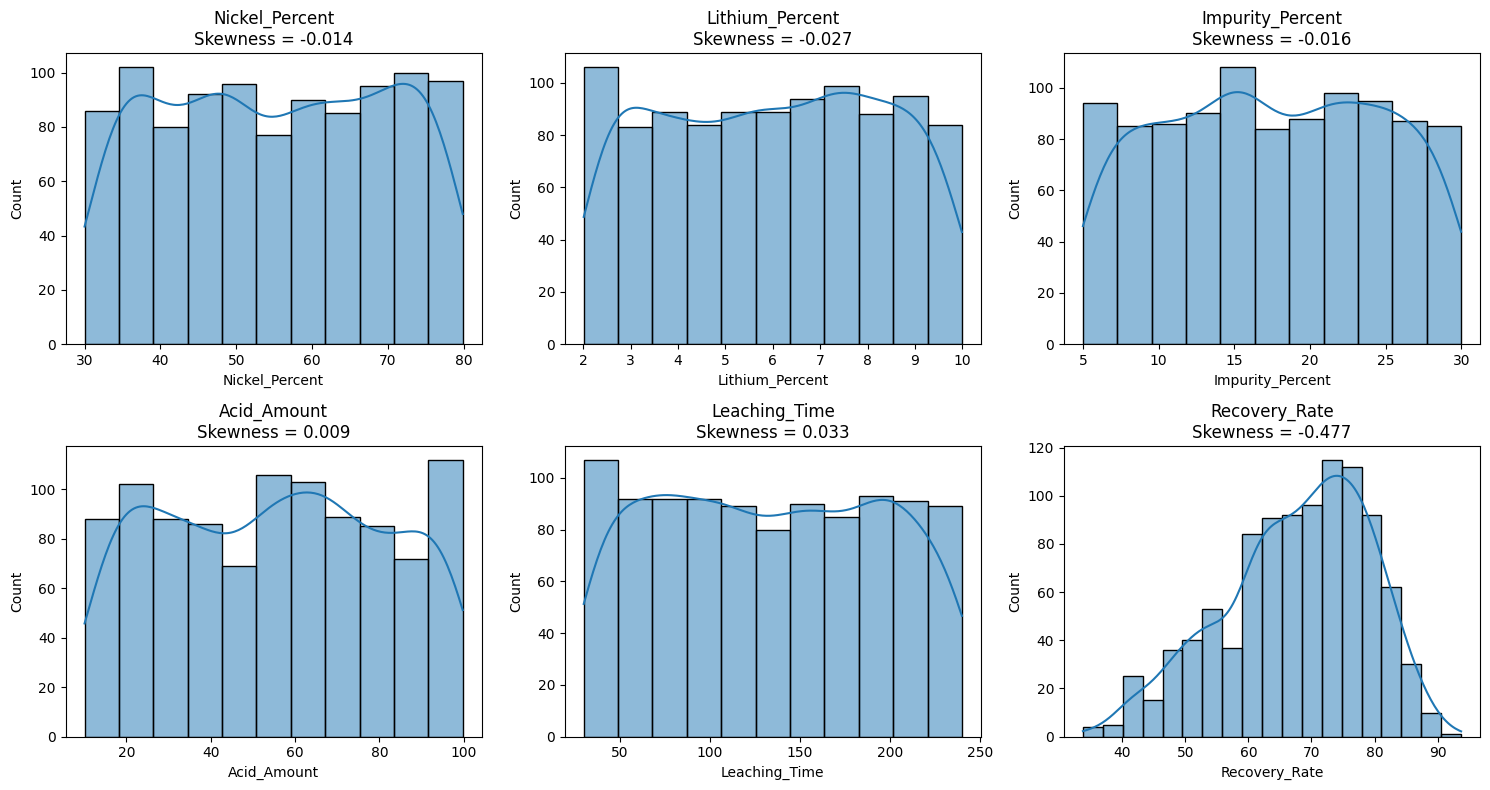

In [138]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

axes = axes.flatten()

for i, col in enumerate(blackpowder_df.columns):

    skewness = blackpowder_df[col].skew()

    sns.histplot(
        data=blackpowder_df,
        x=col,
        kde=True,
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{col}\nSkewness = {skewness:.3f}"
    )

plt.tight_layout()
plt.show()

In [139]:
skew_df = pd.DataFrame({
    "Feature": blackpowder_df.columns,
    "Skewness": [blackpowder_df[col].skew() for col in blackpowder_df.columns]
})

skew_df.sort_values(
    by="Skewness",
    key=abs,
    ascending=False
)

,Feature,Skewness
5,Recovery_Rate,-0.477402
4,Leaching_Time,0.032926
1,Lithium_Percent,-0.026993
2,Impurity_Percent,-0.015940
0,Nickel_Percent,-0.014065
3,Acid_Amount,0.009358


# Pearson Correlation 분석

회수율(Recovery_Rate)과 각 공정 변수 간의 선형 관계를 분석한다.

Pearson Correlation Coefficient는 두 변수 간의 선형 상관관계를 측정하며,
값의 범위는 -1 ~ 1이다.

### 해석 기준

 +1 : 강한 양의 상관관계
 0 : 선형 관계 없음
 -1 : 강한 음의 상관관계

본 분석을 통해 회수율과 선형적으로 관련된 변수들을 탐색한다.

단, Pearson Correlation은 비선형 관계를 반영하지 못하므로
후속 분석에서 Spearman Correlation 및 산점도를 함께 확인한다.

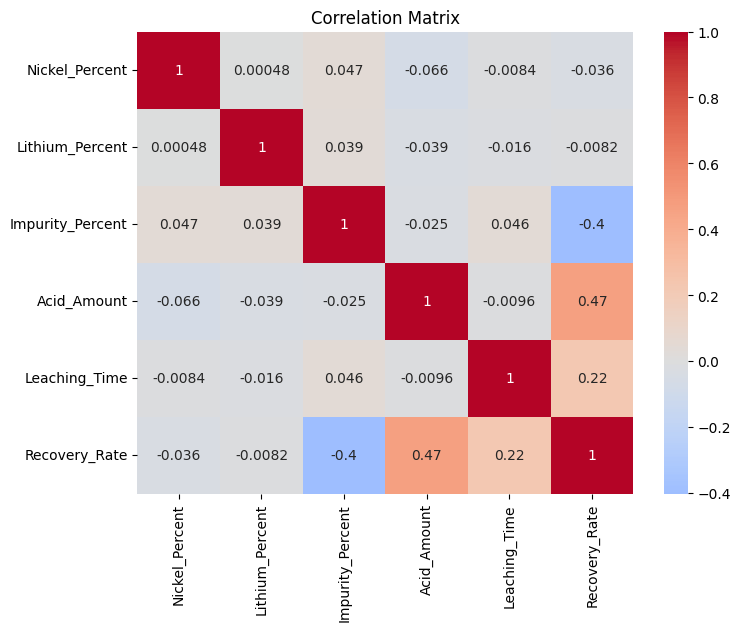

In [ ]:
pearson_corr = blackpowder_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Spearman Correlation 분석

Spearman Correlation은 변수 간의 순위(rank)를 이용하여
단조(monotonic) 관계를 측정한다.

따라서 선형 관계뿐 아니라

- 포화 현상
- 비선형 증가
- 비선형 감소

등도 일부 반영할 수 있다.

Pearson Correlation과 비교하여
회수율과 각 변수 간의 관계를 보다 폭넓게 분석한다.

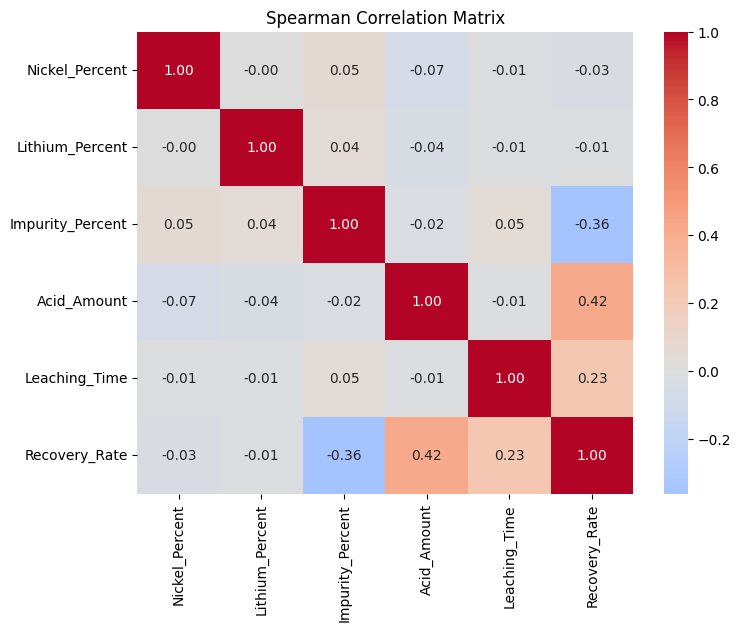

In [ ]:
spearman_corr = blackpowder_df.corr(
    method='spearman'
)

plt.figure(figsize=(8,6))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title(
    'Spearman Correlation Matrix'
)

plt.show()

# 공정 변수와 회수율 관계 분석

각 공정 변수와 회수율 사이의 관계를 시각적으로 분석한다.

본 분석의 목적은 다음과 같다.

- 선형 관계 확인
- 비선형 관계 확인
- 포화 현상 탐색
- 임계값 존재 여부 탐색
- 변수 영향 방향 확인

산점도는 상관계수만으로 확인하기 어려운
패턴을 발견하는 데 활용된다.

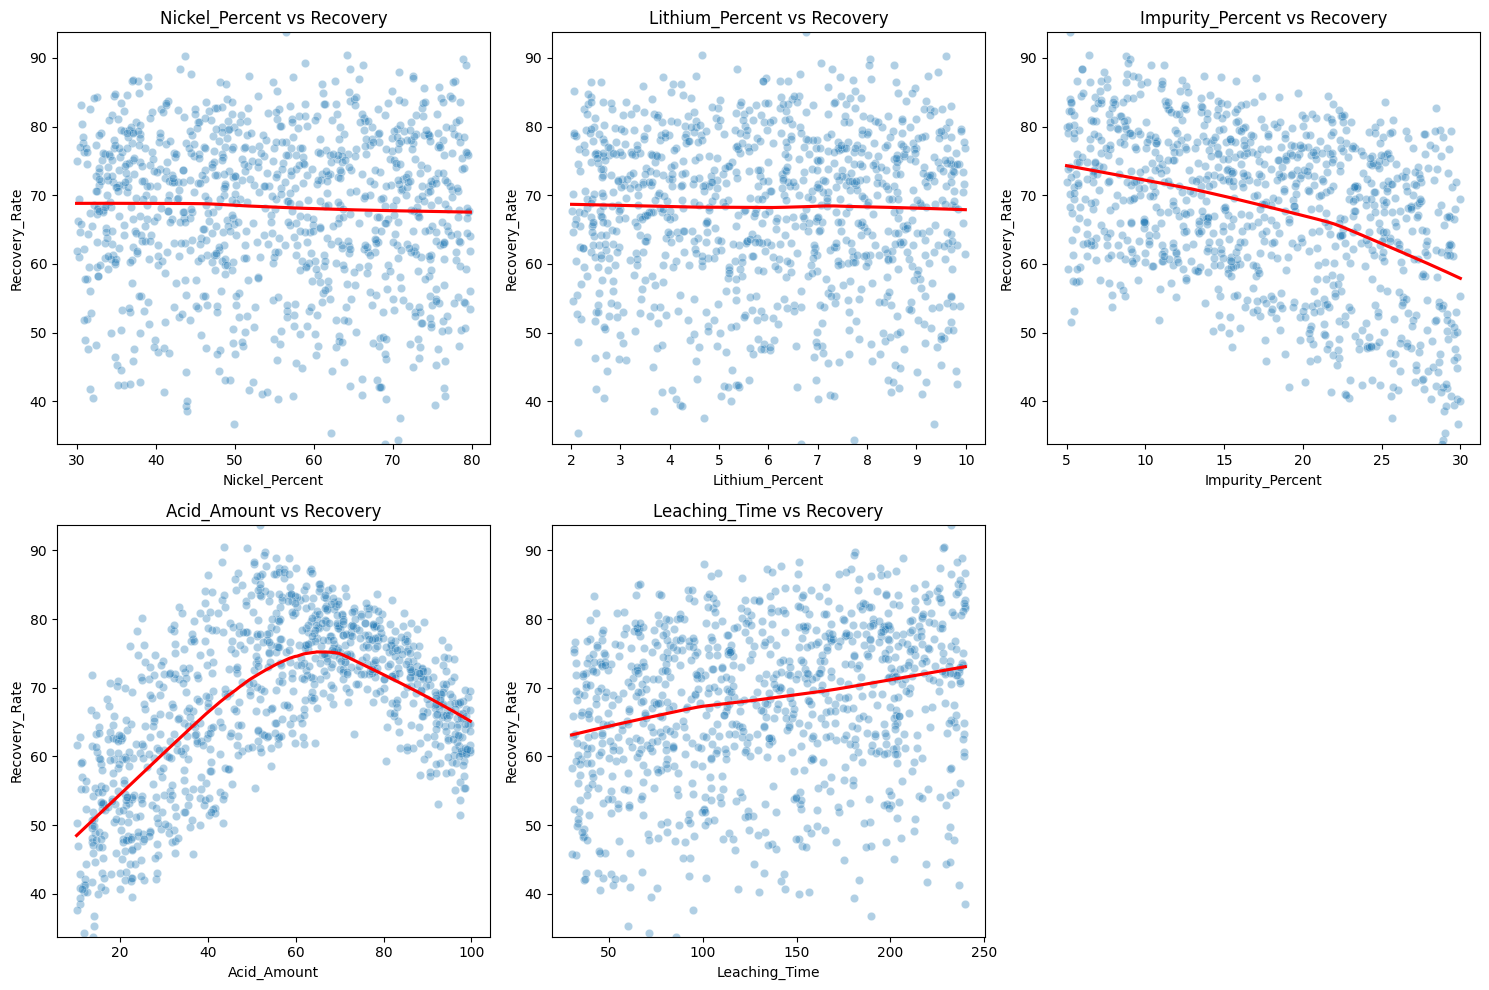

In [65]:
features = [
    'Nickel_Percent',
    'Lithium_Percent',
    'Impurity_Percent',
    'Acid_Amount',
    'Leaching_Time'
]

label = 'Recovery_Rate'

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

y_min = blackpowder_df[label].min()
y_max = blackpowder_df[label].max()

for i, feature in enumerate(features):

    sns.scatterplot(
        data=blackpowder_df,
        x=feature,
        y=label,
        alpha=0.35,
        ax=axes[i]
    )

    sns.regplot(
        data=blackpowder_df,
        x=feature,
        y=label,
        scatter=False,
        lowess=True, # Locally Weighted Scatterplot Smoothing
        color='red',
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} vs Recovery')
    axes[i].set_ylim(y_min, y_max)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

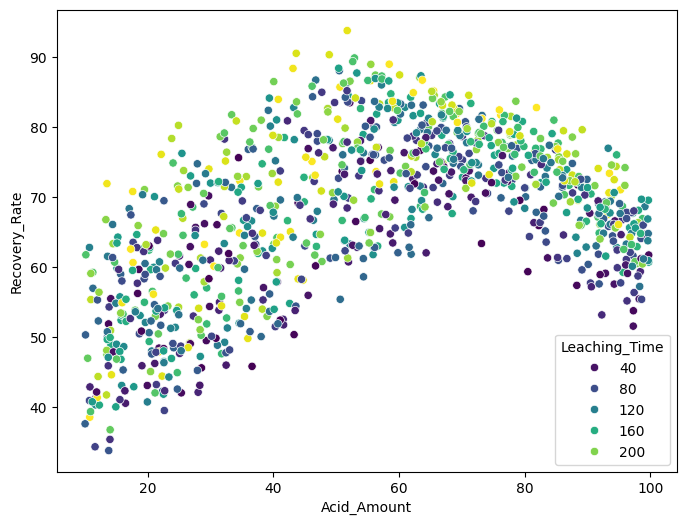

In [66]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=blackpowder_df,
    x='Acid_Amount',
    y='Recovery_Rate',
    hue='Leaching_Time',
    palette='viridis'
)

plt.show()

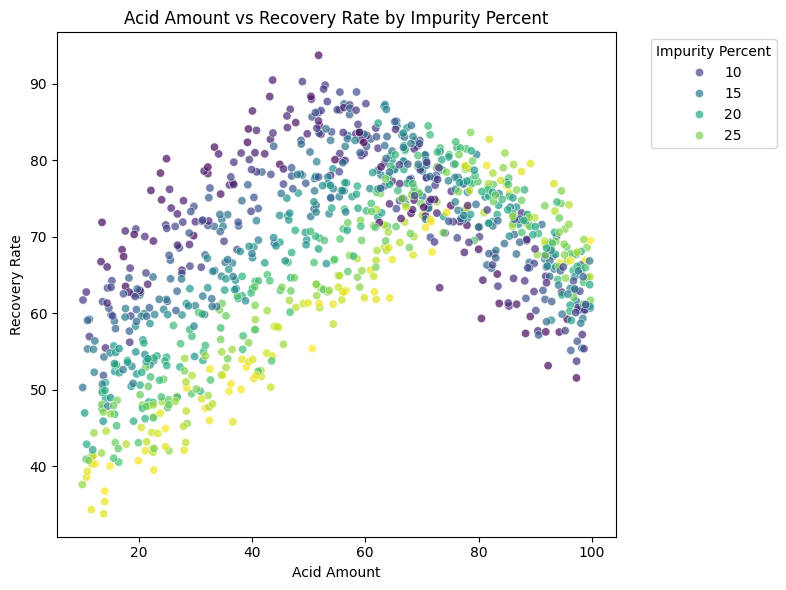

In [124]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=blackpowder_df,
    x='Acid_Amount',
    y='Recovery_Rate',
    hue='Impurity_Percent',
    palette='viridis',
    alpha=0.7
)

plt.title('Acid Amount vs Recovery Rate by Impurity Percent')
plt.xlabel('Acid Amount')
plt.ylabel('Recovery Rate')

plt.legend(
    title='Impurity Percent',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

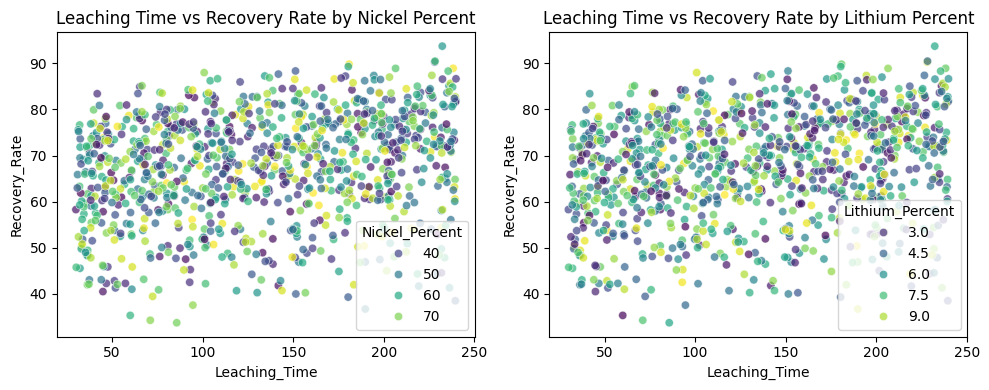

In [120]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)

# Nickel × Time
sns.scatterplot(
    data=blackpowder_df,
    x='Leaching_Time',
    y='Recovery_Rate',
    hue='Nickel_Percent',
    palette='viridis',
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title(
    'Leaching Time vs Recovery Rate by Nickel Percent'
)

# Lithium × Time
sns.scatterplot(
    data=blackpowder_df,
    x='Leaching_Time',
    y='Recovery_Rate',
    hue='Lithium_Percent',
    palette='viridis',
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title(
    'Leaching Time vs Recovery Rate by Lithium Percent'
)

plt.tight_layout()
plt.show()

# Module2. 투입량 대비 회수율 예측 모델링

# 베이스라인 모델 구축

비교 모델은 다음과 같다.

- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

# 데이터 분할

모델의 일반화 성능을 평가하기 위해 데이터를 학습 데이터와 테스트 데이터로 분할하였다.

- Train : 80%
- Test : 20%

모델 선택 및 하이퍼파라미터 탐색은 Train 데이터에 대해 K-Fold Cross Validation을 수행하여 진행한다.

최종 성능 평가는 학습 과정에 사용되지 않은 Test 데이터에서 수행한다.

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

features = [
    'Nickel_Percent',
    'Lithium_Percent',
    'Impurity_Percent',
    'Acid_Amount',
    'Leaching_Time'
]

label = 'Recovery_Rate'

X = blackpowder_df[features]
y = blackpowder_df[label]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f'Train : {len(X_train)}')
print(f'Test  : {len(X_test)}')

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Train : 800
Test  : 200


# 평가 함수

In [69]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


def evaluate_model(model, X_test, y_test):

    pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    return mae, rmse, r2

In [75]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Linear Regression 모델 학습

In [83]:
lr = LinearRegression()

lr_result = cross_validate(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring=[
        'r2',
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error'
    ]
)

print(f"Mean R²   : {np.mean(lr_result['test_r2']):.4f}")
print(f"Mean MAE  : {-np.mean(lr_result['test_neg_mean_absolute_error']):.4f}")
print(f"Mean RMSE : {-np.mean(lr_result['test_neg_root_mean_squared_error']):.4f}")

Mean R²   : 0.4170
Mean MAE  : 7.1755
Mean RMSE : 8.7268


# Random Forest 모델 학습

In [84]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_result = cross_validate(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring=[
        'r2',
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error'
    ]
)

print(f"Mean R²   : {np.mean(rf_result['test_r2']):.4f}")
print(f"Mean MAE  : {-np.mean(rf_result['test_neg_mean_absolute_error']):.4f}")
print(f"Mean RMSE : {-np.mean(rf_result['test_neg_root_mean_squared_error']):.4f}")

Mean R²   : 0.9417
Mean MAE  : 2.2232
Mean RMSE : 2.7624


# LightGBM 모델 학습

In [85]:
lgbm = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

lgbm_result = cross_validate(
    lgbm,
    X_train,
    y_train,
    cv=5,
    scoring=[
        'r2',
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error'
    ]
)

print(f"Mean R²   : {np.mean(lgbm_result['test_r2']):.4f}")
print(f"Mean MAE  : {-np.mean(lgbm_result['test_neg_mean_absolute_error']):.4f}")
print(f"Mean RMSE : {-np.mean(lgbm_result['test_neg_root_mean_squared_error']):.4f}")
# lgb.plot_importance(lgbm)

Mean R²   : 0.9443
Mean MAE  : 2.1755
Mean RMSE : 2.6958


# XGBoost 모델 학습

In [86]:
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_result = cross_validate(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring=[
        'r2',
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error'
    ]
)

print(f"Mean R²   : {np.mean(xgb_result['test_r2']):.4f}")
print(f"Mean MAE  : {-np.mean(xgb_result['test_neg_mean_absolute_error']):.4f}")
print(f"Mean RMSE : {-np.mean(xgb_result['test_neg_root_mean_squared_error']):.4f}")

Mean R²   : 0.9394
Mean MAE  : 2.2761
Mean RMSE : 2.8184


# 모델 성능 비교

In [89]:
result_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'LightGBM',
        'XGBoost'
    ],
    'Mean R2': [
        np.mean(lr_result['test_r2']),
        np.mean(rf_result['test_r2']),
        np.mean(lgbm_result['test_r2']),
        np.mean(xgb_result['test_r2'])
    ],
    'Mean MAE': [
        -np.mean(lr_result['test_neg_mean_absolute_error']),
        -np.mean(rf_result['test_neg_mean_absolute_error']),
        -np.mean(lgbm_result['test_neg_mean_absolute_error']),
        -np.mean(xgb_result['test_neg_mean_absolute_error'])
    ],
    'Mean RMSE': [
        -np.mean(lr_result['test_neg_root_mean_squared_error']),
        -np.mean(rf_result['test_neg_root_mean_squared_error']),
        -np.mean(lgbm_result['test_neg_root_mean_squared_error']),
        -np.mean(xgb_result['test_neg_root_mean_squared_error'])
    ]
})

result_df.sort_values(
    by='Mean RMSE',
    ascending=True
)

,Model,Mean R2,Mean MAE,Mean RMSE
2,LightGBM,0.944338,2.175520,2.695838
1,Random Forest,0.941681,2.223161,2.762383
3,XGBoost,0.939392,2.276075,2.818393
0,Linear Regression,0.416979,7.175528,8.726767


# LightGBM 모델 예측

In [107]:
baseline_best_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

baseline_best_model.fit(
    X_train,
    y_train
)

LGBMRegressor(learning_rate=0.05, n_estimators=200, random_state=42, verbose=-1)

# LightGBM 모델 평가

In [108]:
test_mae, test_rmse, test_r2 = evaluate_model(
    baseline_best_model,
    X_test,
    y_test
)

print(f"Test R²   : {test_r2:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")

Test R²   : 0.9559
Test MAE  : 1.8672
Test RMSE : 2.3624


# SHAP

In [109]:
import shap
explainer = shap.TreeExplainer(
    baseline_best_model
)

shap_values = explainer.shap_values(
    X_train
)

# SHAP Summary

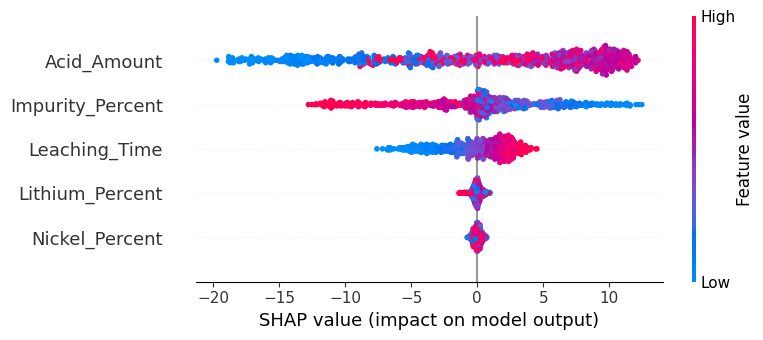

In [110]:
shap.summary_plot(
    shap_values,
    X_train
)

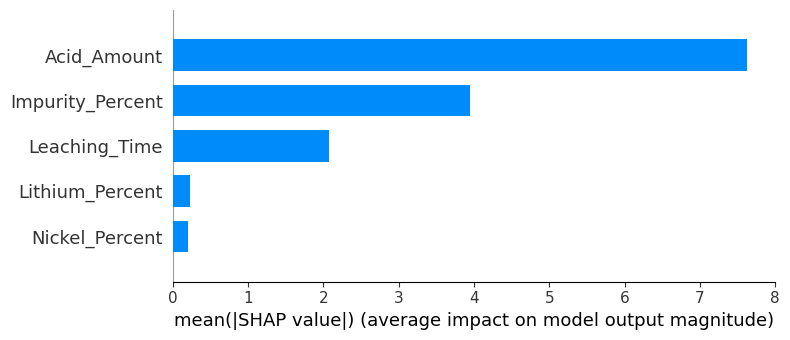

In [111]:
shap.summary_plot(
    shap_values,
    X_train,
    plot_type='bar'
)

# SHAP Dependence

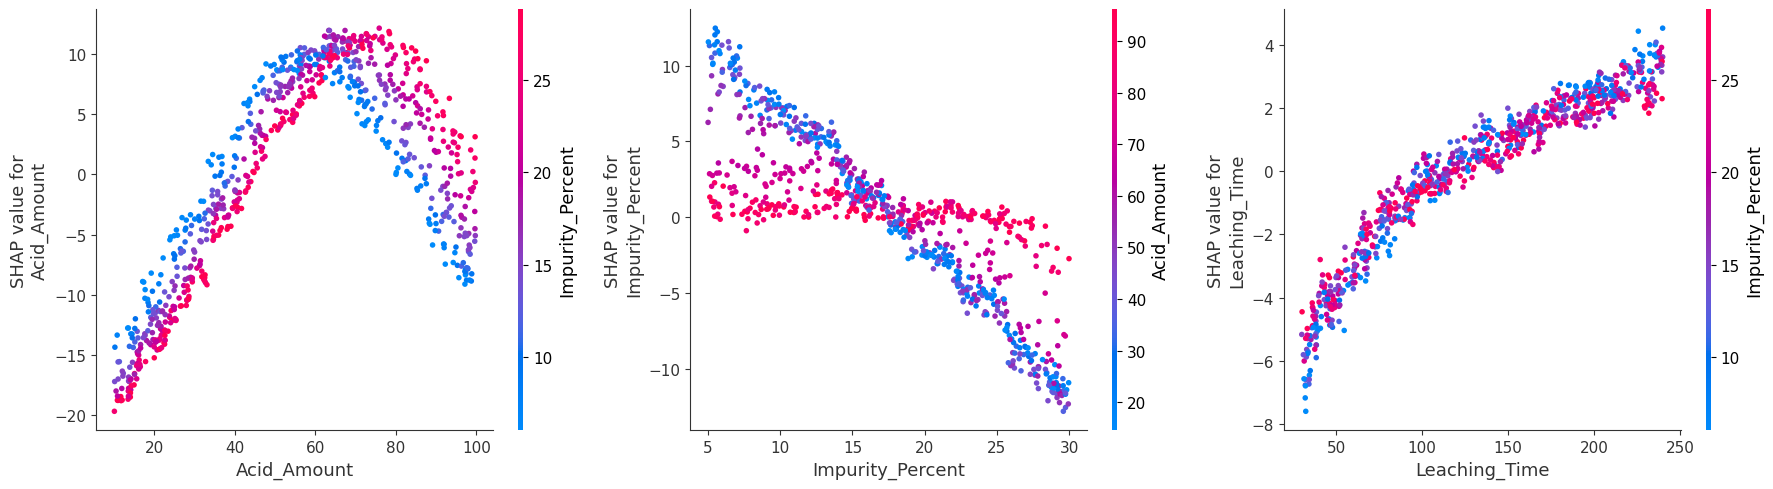

In [133]:
features = [
    'Acid_Amount',
    'Impurity_Percent',
    'Leaching_Time'
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for i, feature in enumerate(features):

    plt.sca(axes[i])

    shap.dependence_plot(
        feature,
        shap_values,
        X_train,
        ax=axes[i],
        show=False
    )

plt.tight_layout()
plt.show()

# PDP

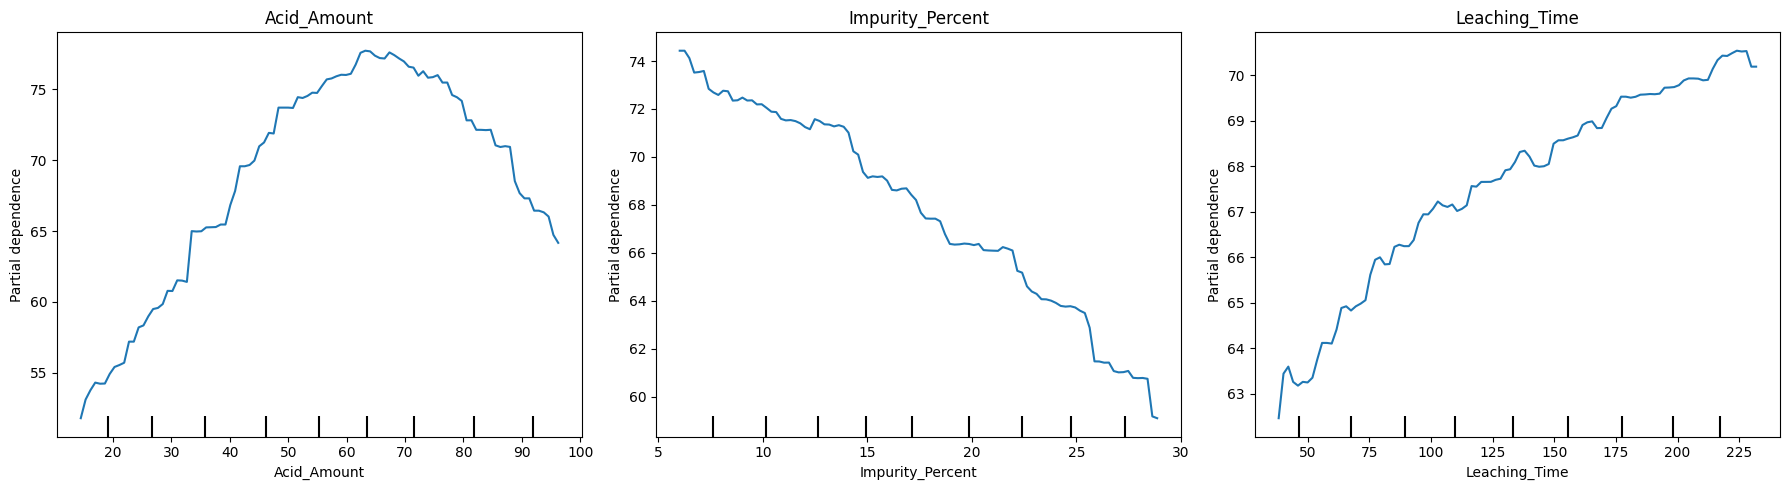

In [125]:
from sklearn.inspection import PartialDependenceDisplay

features = [
    'Acid_Amount',
    'Impurity_Percent',
    'Leaching_Time'
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for i, feature in enumerate(features):

    PartialDependenceDisplay.from_estimator(
        baseline_best_model,
        X_train,
        [feature],
        ax=axes[i]
    )

    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

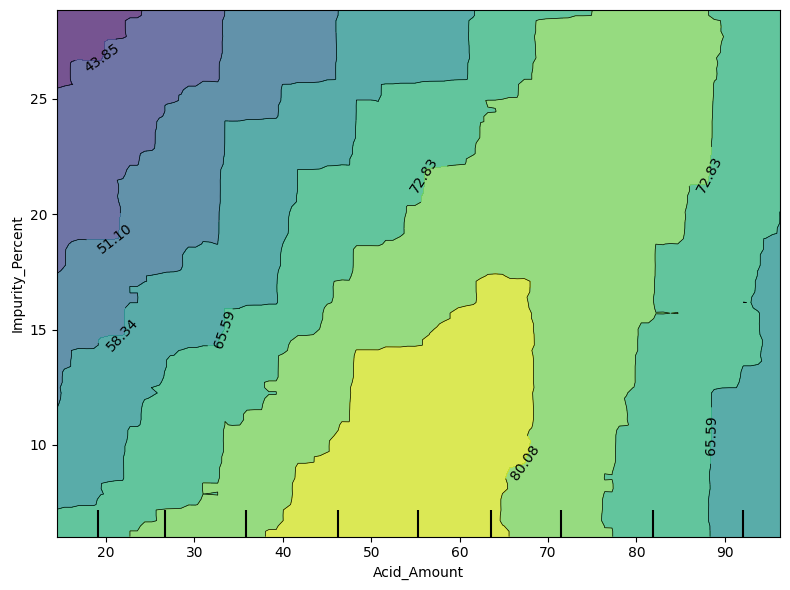

In [126]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(
    figsize=(8, 6)
)

PartialDependenceDisplay.from_estimator(
    baseline_best_model,
    X_train,
    [('Acid_Amount', 'Impurity_Percent')],
    ax=ax
)

plt.tight_layout()
plt.show()

# LightGBM (파생변수 Acid_per_Impurity 추가) 모델 학습

In [135]:
from sklearn.model_selection import train_test_split, cross_validate
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np

feature_engineered_df = blackpowder_df.copy()

feature_engineered_df['Acid_per_Impurity'] = (
    feature_engineered_df['Acid_Amount']
    / feature_engineered_df['Impurity_Percent']
)

features_fe = [
    'Nickel_Percent',
    'Lithium_Percent',
    'Impurity_Percent',
    'Acid_Amount',
    'Leaching_Time',
    'Acid_per_Impurity'
]

label = 'Recovery_Rate'

X_fe = feature_engineered_df[features_fe]
y_fe = feature_engineered_df[label]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42
)

lgbm_fe = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

lgbm_fe_result = cross_validate(
    lgbm_fe,
    X_train_fe,
    y_train_fe,
    cv=5,
    scoring=[
        'r2',
        'neg_mean_absolute_error',
        'neg_root_mean_squared_error'
    ]
)

print("LightGBM + Acid_per_Impurity")
print(f"Mean R²   : {np.mean(lgbm_fe_result['test_r2']):.4f}")
print(f"Mean MAE  : {-np.mean(lgbm_fe_result['test_neg_mean_absolute_error']):.4f}")
print(f"Mean RMSE : {-np.mean(lgbm_fe_result['test_neg_root_mean_squared_error']):.4f}")

LightGBM + Acid_per_Impurity
Mean R²   : 0.9524
Mean MAE  : 2.0021
Mean RMSE : 2.4915


In [136]:
compare_lgbm_df = pd.DataFrame({
    'Model': [
        'LightGBM Original',
        'LightGBM + Acid_per_Impurity'
    ],
    'Mean R2': [
        np.mean(lgbm_result['test_r2']),
        np.mean(lgbm_fe_result['test_r2'])
    ],
    'Mean MAE': [
        -np.mean(lgbm_result['test_neg_mean_absolute_error']),
        -np.mean(lgbm_fe_result['test_neg_mean_absolute_error'])
    ],
    'Mean RMSE': [
        -np.mean(lgbm_result['test_neg_root_mean_squared_error']),
        -np.mean(lgbm_fe_result['test_neg_root_mean_squared_error'])
    ]
})

compare_lgbm_df

,Model,Mean R2,Mean MAE,Mean RMSE
0,LightGBM Original,0.944338,2.175520,2.695838
1,LightGBM + Acid_per_Impurity,0.952427,2.002077,2.491475
